# Temperature Prediction — Nuclear Waste Storage Tunnel

### **Group**: 12
### **Authors**: Anna Billon, Eva Kupecek

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.neighbors import KDTree
from sklearn.inspection import permutation_importance

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print('Imports OK.')

Imports OK.


In [2]:
# Data paths
REPO_ROOT = Path('.').resolve()

for _candidate in [
    REPO_ROOT / 'data_parquet_2026' / 'data_parquet_2026',
    REPO_ROOT / 'data_parquet_2026',
]:
    if (_candidate / 'train.parquet').exists():
        RAW_DIR = _candidate
        break

PROCESSED_DIR   = REPO_ROOT / 'data' / 'processed'
SUBMISSIONS_DIR = REPO_ROOT / 'submissions'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

SECONDS_PER_YEAR = 365.25 * 24 * 3600
RANDOM_STATE     = 42
TARGET           = 'temperature'

# Load raw files
train_raw = pd.read_parquet(RAW_DIR / 'train.parquet')
test_raw  = pd.read_parquet(RAW_DIR / 'test.parquet')
sensors   = pd.read_parquet(RAW_DIR / 'sensors.parquet')

# Merge 3D coordinates into train and test
sensors_unique = sensors.groupby('sensor', as_index=False).mean(numeric_only=True)
train_raw = train_raw.merge(sensors_unique, on='sensor', how='left')
test_raw  = test_raw.merge(sensors_unique,  on='sensor', how='left')

print(f'train : {train_raw.shape}')
print(f'test  : {test_raw.shape}')
print(f'\nTrain columns : {train_raw.columns.tolist()}')
train_raw.head(3)

train : (6626928, 7)
test  : (2190480, 6)

Train columns : ['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y', 'coor_z']


,sensor,time,power,temperature,coor_x,coor_y,coor_z
0,N102,0.0,1487.964722,17.514429,46.131474,3.5,0.0
1,N102,864000.0,1487.288818,17.820795,46.131474,3.5,0.0
2,N102,1728000.0,1486.612915,17.573187,46.131474,3.5,0.0


## 1. Data Cleaning

### Why clean?

Exploration of the raw data reveals three major issues:
- **Physically impossible temperatures** (< 0 °C or > 200 °C in this context)
- **Isolated outliers** caused by sensor malfunctions
- **Fully failed sensors** throughout their entire lifetime

Leaving these values in the training set would bias the model: it would learn to reproduce instrumental anomalies rather than the actual physics of the tunnel.

---

### Strategy: 4 cascaded filters

| Step | Type | Threshold | Justification |
|------|------|-----------|---------------|
| 1 | **Physical limits** | [0, 200] °C | Below 0 °C = impossible in an active storage tunnel. Above 200 °C = unrealistic. Bounds are wide to avoid masking truly high values near the heat source. |
| 2 | **IQR outliers per sensor** | 4 × IQR | IQR is computed *per sensor*: each sensor has its own normal range depending on its position. The 4× factor is conservative — a standard 1.5× would remove genuine extreme physical values. |
| 3 | **Temporal spikes** | window = 21, z > 8 σ | A spike = isolated value very different from its temporal neighbours. We use a **robust z-score** based on MAD (Median Absolute Deviation), since the mean is too sensitive to outliers themselves. Threshold of 8 σ is intentionally high to only remove clear anomalies. |
| 4 | **Failed sensors** | > 20% bad readings | A sensor with more than 20% corrupted data contributes more noise than information. |

### Order of operations

**Physical limits are applied first**, before computing the IQR. Without this, extreme values (e.g. −9999 °C) would inflate the IQR and mask moderate true outliers.

### Philosophy: permissive thresholds

We prefer to **remove little but confidently**: better to keep a doubtful value than to discard a genuine extreme physical value. The final result removes ~4.7% of rows — reasonable.


In [3]:
# Cleaning parameters
TEMP_MIN         = 0.0
TEMP_MAX         = 200.0
IQR_MULTIPLIER   = 4.0
ROLLING_WINDOW   = 21
ROLLING_Z_LIMIT  = 8.0
MAX_BAD_FRACTION = 0.20


def create_cleaning_flags(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds boolean flag columns without removing any rows.

    flag_missing  : missing temperature
    flag_physical : outside physical limits [0, 200] °C
    flag_iqr      : IQR outlier per sensor (4x)
    flag_spike    : temporal spike (robust z-score on rolling window)
    flag_bad      : union of all flags above
    """
    df = df.copy()

    # Step 1 — Physical limits
    df['flag_missing']  = df['temperature'].isna()
    df['flag_physical'] = (
        df['temperature'].notna()
        & ((df['temperature'] < TEMP_MIN) | (df['temperature'] > TEMP_MAX))
    )

    # Step 2 — IQR per sensor (computed on physically valid values)
    valid = df['temperature'].notna() & ~df['flag_physical']
    q1 = df.loc[valid].groupby('sensor', observed=True)['temperature'].quantile(0.25)
    q3 = df.loc[valid].groupby('sensor', observed=True)['temperature'].quantile(0.75)
    iqr = q3 - q1
    bounds = pd.DataFrame({
        'sensor': q1.index,
        'lower':  (q1 - IQR_MULTIPLIER * iqr).values,
        'upper':  (q3 + IQR_MULTIPLIER * iqr).values,
    })
    df = df.merge(bounds, on='sensor', how='left', validate='many_to_one')
    df['flag_iqr'] = (
        valid & df['lower'].notna()
        & ((df['temperature'] < df['lower']) | (df['temperature'] > df['upper']))
    )
    df.drop(columns=['lower', 'upper'], inplace=True)

    # Step 3 — Temporal spikes (robust z-score on rolling window)
    df = df.sort_values(['sensor', 'time']).reset_index(drop=True)
    rolling_med = (
        df.groupby('sensor', observed=True)['temperature']
        .transform(lambda s: s.rolling(ROLLING_WINDOW, center=True, min_periods=5).median())
    )
    residual = df['temperature'] - rolling_med
    mad      = residual.abs().groupby(df['sensor'], observed=True).transform('median')
    robust_z = residual.abs() / (1.4826 * mad + 1e-6)
    df['flag_spike'] = (
        df['temperature'].notna() & rolling_med.notna() & (robust_z > ROLLING_Z_LIMIT)
    )

    # Global flag
    df['flag_bad'] = (
        df['flag_missing'] | df['flag_physical'] | df['flag_iqr'] | df['flag_spike']
    )
    return df


def identify_failed_sensors(flagged: pd.DataFrame) -> set:
    """
    Returns sensors with more than MAX_BAD_FRACTION of bad readings.
    These sensors are fully excluded from training.
    """
    stats = flagged.groupby('sensor', observed=True)['flag_bad'].agg(['sum', 'count'])
    stats['bad_frac'] = stats['sum'] / stats['count']
    return set(stats[stats['bad_frac'] > MAX_BAD_FRACTION].index.astype(str))


def clean_train_data(flagged: pd.DataFrame, failed_sensors: set) -> pd.DataFrame:
    """Remove bad rows and failed sensors."""
    flag_cols = [c for c in flagged.columns if c.startswith('flag_')]
    return (
        flagged
        .loc[~flagged['flag_bad']]
        .loc[~flagged['sensor'].astype(str).isin(failed_sensors)]
        .drop(columns=flag_cols)
        .reset_index(drop=True)
    )


print('Cleaning functions defined.')

Cleaning functions defined.


In [ ]:
# Run cleaning
print('Cleaning in progress...')
flagged        = create_cleaning_flags(train_raw)
failed_sensors = identify_failed_sensors(flagged)
train_cleaned  = clean_train_data(flagged, failed_sensors)

n_removed = len(train_raw) - len(train_cleaned)
print(f"\n{'='*52}")
print(f'  Original rows             : {len(train_raw):>10,}')
print(f'  Missing temperatures      : {flagged["flag_missing"].sum():>10,}')
print(f'  Outside physical limits   : {flagged["flag_physical"].sum():>10,}')
print(f'  IQR outliers              : {flagged["flag_iqr"].sum():>10,}')
print(f'  Temporal spikes           : {flagged["flag_spike"].sum():>10,}')
print(f'  Failed sensors            : {len(failed_sensors):>10}')
print(f'  ----------------------------------------')
print(f'  Removed rows (total)      : {n_removed:>10,}  ({n_removed/len(train_raw):.1%})')
print(f'  Cleaned rows              : {len(train_cleaned):>10,}')
print(f'  Active sensors            : {train_cleaned["sensor"].nunique():>10}')
print(f"{'='*52}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution avant/après — raw en contour, cleaned en rempli
ax = axes[0]
plot_range = (-10, 210)
raw_clipped     = flagged['temperature'].dropna().clip(*plot_range)
cleaned_clipped = train_cleaned['temperature'].clip(*plot_range)
ax.hist(cleaned_clipped, bins=100, alpha=0.7, color='steelblue', density=True,
        label=f'Cleaned ({len(train_cleaned):,} rows)')
ax.hist(raw_clipped, bins=100, density=True, histtype='step',
        color='tomato', linewidth=1.5, label=f'Raw ({len(train_raw):,} rows)')
ax.set_xlim(plot_range)
ax.set_xlabel('Temperature (°C)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Distribution before / after cleaning', fontsize=12)
ax.legend(fontsize=10)

# Outliers par type
ax = axes[1]
counts = {
    'Missing':           int(flagged['flag_missing'].sum()),
    'Physical\nlimits':  int(flagged['flag_physical'].sum()),
    'IQR':               int(flagged['flag_iqr'].sum()),
    'Temporal\nspikes':  int(flagged['flag_spike'].sum()),
}
bar_colors = ['#4878CF', '#E24A33', '#6ACC65', '#956CB4']
bars = ax.bar(counts.keys(), counts.values(), color=bar_colors, alpha=0.85)
ax.set_ylabel('Removed rows', fontsize=11)
ax.set_title('Outliers breakdown by type', fontsize=12)
for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{v:,}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, max(counts.values()) * 1.15)

plt.tight_layout()
plt.show()

### Cleaning results — analysis

**Left plot — Temperature distribution before/after cleaning:**
The raw distribution (salmon) is essentially invisible because a small number of sensors report physically absurd values (e.g. −9999 °C or +9999 °C), which compress the entire distribution into a thin line near zero on the x-axis. After cleaning (blue), the distribution reveals the actual temperature range of the tunnel: most sensors read between 10 °C and 80 °C, with a long tail toward higher values near the canister.

**Right plot — Outliers breakdown by type:**
- **Physical limits (189,900 rows)** is the dominant category, confirming that a subset of sensors occasionally report sentinel failure values far outside any physical range. Removing these first is critical — they would otherwise inflate the IQR of those sensors and hide moderate true outliers.
- **Missing values (99,403)** represent sensors that simply stopped recording, likely due to power or connection failures.
- **Temporal spikes (40,808)** are brief isolated anomalies — a sensor reading that jumps far from its neighbours before returning to normal. These are instrument glitches, not physical events.
- **IQR outliers (8,819)** are the smallest category: moderate values that fall outside each sensor's expected range once the gross failures above have already been removed.

The cascaded order (physical → IQR → spikes → failed sensors) ensures each filter operates on already-cleaned data, avoiding contamination of statistics by upstream outliers.

## 2. Feature Engineering

The raw dataset provides: `sensor`, `time`, `power`, `temperature`, and 3D coordinates (`coor_x`, `coor_y`, `coor_z`).

We engineer 6 additional base features capturing the physics of heat diffusion:

| Feature | Formula | Physical meaning |
|---|---|---|
| `r_xy` | `√(x² + y²)` | 2D radial distance to canister |
| `r_xyz` | `√(x² + y² + z²)` | 3D distance to origin |
| `time_years` | `time / (365.25 × 24 × 3600)` | Time in years |
| `abs_y` | `\|y\|` | Vertical position |
| `power_x_time` | `power × time_years` | Cumulative energy proxy |
| `power_over_r_xy` | `power / r_xy` | Heat flux proxy (most important feature) |

**Key geometric insight:** The tunnel cross-section shows a **rectangular buffer zone** directly adjacent to the canister. The Buffer/OPA boundary is a **vertical line at coor_x = 1.4 m** — not a circle. Sensors with `coor_x > 1.4 m` are in OPA (Opalinus Clay).

Features added. Train shape: (6180661, 13)
Columns: ['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y', 'coor_z', 'r_xy', 'r_xyz', 'time_years', 'abs_y', 'power_x_time', 'power_over_r_xy']


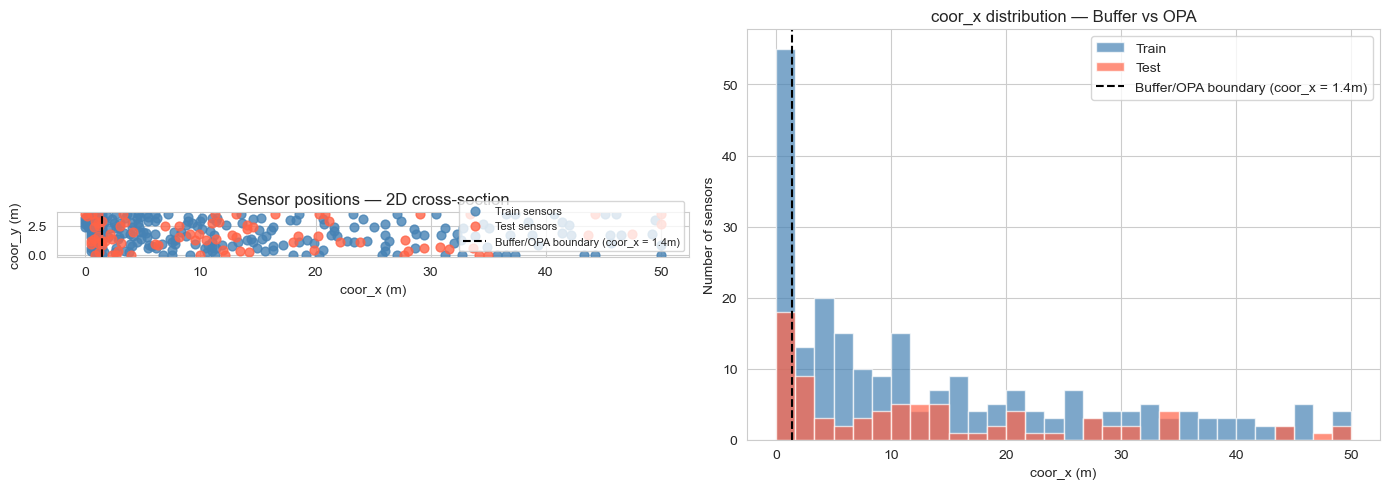

In [5]:
def add_base_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add engineered features to train or test dataframe."""
    df = df.copy()
    df['r_xy']           = np.sqrt(df['coor_x']**2 + df['coor_y']**2)
    df['r_xyz']          = np.sqrt(df['coor_x']**2 + df['coor_y']**2 + df['coor_z']**2)
    df['time_years']     = df['time'] / (365.25 * 24 * 3600)
    df['abs_y']          = df['coor_y'].abs()
    df['power_x_time']   = df['power'] * df['time_years']
    df['power_over_r_xy']= df['power'] / (df['r_xy'] + 1e-9)
    return df

train_cleaned = add_base_features(train_cleaned)
test_feat     = add_base_features(test_raw)

print(f"Features added. Train shape: {train_cleaned.shape}")
print(f"Columns: {train_cleaned.columns.tolist()}")

# Sensor geometry visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sensors_train = train_cleaned.groupby('sensor')[['coor_x', 'coor_y', 'r_xy']].mean()
sensors_test  = test_feat.groupby('sensor')[['coor_x', 'coor_y', 'r_xy']].mean()

ax = axes[0]
ax.scatter(sensors_train['coor_x'], sensors_train['coor_y'], c='steelblue', s=40, label='Train sensors', alpha=0.8)
ax.scatter(sensors_test['coor_x'],  sensors_test['coor_y'],  c='tomato',    s=40, label='Test sensors',  alpha=0.8)
ax.axvline(x=1.4, color='black', linestyle='--', linewidth=1.5, label='Buffer/OPA boundary (coor_x = 1.4m)')
ax.set_aspect('equal'); ax.set_xlabel('coor_x (m)'); ax.set_ylabel('coor_y (m)')
ax.set_title('Sensor positions — 2D cross-section'); ax.legend(fontsize=8)

ax = axes[1]
ax.hist(sensors_train['coor_x'], bins=30, color='steelblue', alpha=0.7, label='Train')
ax.hist(sensors_test['coor_x'],  bins=30, color='tomato',    alpha=0.7, label='Test')
ax.axvline(1.4, color='black', linestyle='--', label='Buffer/OPA boundary (coor_x = 1.4m)')
ax.set_xlabel('coor_x (m)'); ax.set_ylabel('Number of sensors')
ax.set_title('coor_x distribution — Buffer vs OPA'); ax.legend()

plt.tight_layout()
plt.show()

### Geometry analysis

**Left plot — Sensor positions:**
The tunnel cross-section reveals a strongly elongated geometry: sensors span ~50 m along `coor_x` but only ~3 m along `coor_y`. The vertical dashed line at `coor_x = 1.4 m` marks the Buffer/OPA boundary. The canister (heat source) sits at the origin. Only a handful of sensors are in the buffer zone (left of the line) — these are the hottest sensors and the easiest to predict. The vast majority lie in OPA, spread over tens of metres, where temperatures are lower and spatial gradients are smaller.

Test sensors (red) are well distributed across the full range of `coor_x`, meaning the model must generalise to both near-canister and far-field positions.

**Right plot — coor_x distribution:**
The sharp peak just above 1.4 m confirms that most sensors are clustered just outside the buffer boundary, in the early OPA zone. This is physically consistent: monitoring is densest where thermal gradients are steepest. Beyond ~10 m, sensor density drops and the model must interpolate over larger gaps — this is where prediction error tends to be highest.

## 3. Model Architecture

### The core challenge

This is a **spatial interpolation problem**: at each timestep t, we observe temperatures at 222 train sensors and must predict temperatures at 80 unseen test sensor positions. The key insight is that temperature at any position is not independent — it is physically determined by the distance to the heat source and the temperatures of neighbouring sensors.

A naive model that only uses position + time as inputs would have to learn the entire thermal physics from scratch. Instead, we compute **spatial features** that summarise what the known sensors are already measuring at that moment, then let HistGB learn the residual corrections.

---

### 3.1 IDW — Inverse Distance Weighting

At each timestep t, the 222 train sensors form a spatial temperature field. IDW estimates the temperature at any query position j by taking a weighted average of all known sensor temperatures, where each weight decreases with the square of the distance:

$$T_{\text{IDW}}(j, t) = \frac{\displaystyle\sum_i \frac{T_i(t)}{d(j,i)^2}}{\displaystyle\sum_i \frac{1}{d(j,i)^2}}$$

**Why IDW?** It is physically motivated — temperature diffuses through the rock and the influence of a sensor naturally decreases with distance. IDW is parameter-free (no training required) and provides a strong global prior over the entire sensor field.

**IDW as a feature, not a prediction:** IDW alone is a weak temporal predictor (it knows nothing about time, power, or material properties). It is used as an input **feature** to HistGB, which then learns to correct for its biases.

**Why global (all 222 sensors) and not local (k nearest)?** We tested local IDW with k=20 — it performed worse (Kaggle: 4.2 vs 3.42). With only k=20 sensors, the estimate is noisier and more sensitive to the specific sensors chosen. Using all 222 sensors averages out local noise and provides a more stable estimate.

---

### 3.2 KNN Hybrid Features

In addition to the global IDW, we extract the temperatures of the physically nearest sensors at each timestep:

| Feature | Description |
|---|---|
| `nn_temp` | Temperature of the single closest train sensor |
| `nn_dist` | Distance to that closest sensor |
| `broad_temp_mean` | Mean temperature of the 5 nearest sensors |
| `broad_temp_std` | Std of those 5 temperatures |

**Why KNN on top of IDW?** IDW already uses all sensors, but treats near and far sensors symmetrically (via the 1/d² weighting). The KNN features give HistGB direct access to the immediate spatial neighbourhood — the single nearest neighbour temperature is often the strongest individual predictor.

---

### 3.3 HistGradientBoostingRegressor

HistGB is a gradient-boosted tree algorithm that learns to predict temperature from all 16 features jointly. It is well-suited to this problem because:

- **Handles mixed feature types** — coordinates, time, power, and spatial estimates all on different scales
- **Captures non-linear interactions** — e.g. the relationship between `power_over_r_xy` and temperature changes over time as the rock saturates
- **Early stopping** — training halts when validation loss stops improving, preventing overfitting

HistGB is trained to predict temperature **directly** (not residuals). The IDW and KNN features give it a strong starting point; it learns where those estimates are systematically wrong (material boundaries, temporal transients, etc.).

---

### 3.4 Validation strategy

**Sensor-level split**: entire sensors are held out for validation — no individual rows from a validation sensor appear in training. This is critical because our spatial features (IDW, KNN) look up temperatures from training sensors at each timestep. If a validation sensor were used as a source for these features, the model would have indirect access to its temperature and the validation would be optimistic.

| Set | Sensors | Rows |
|---|---|---|
| Training | ~185 (80%) | ~4,930,000 |
| Validation | ~47 (20%) | ~1,250,000 |

In [6]:
# ----------------------------
# Configuration
# ----------------------------
K_BROAD   = 5
IDW_POWER = 2
TARGET    = 'temperature'

# Buffer/OPA boundary: vertical line at x = 1.4m (NOT a circle).
# The buffer is a rectangular zone directly adjacent to the canister (left side).
# Sensors with coor_x > 1.4m are in OPA.
BUFFER_X = 1.4

BASE_FEATURES = [
    'time', 'power',
    'coor_x', 'coor_y', 'coor_z',
    'time_years', 'r_xy', 'r_xyz', 'abs_y',
    'power_x_time', 'power_over_r_xy',
]
IDW_FEATURES     = ['idw_temp']
SPATIAL_FEATURES = ['nn_temp', 'nn_dist', 'broad_temp_mean', 'broad_temp_std']
ALL_FEATURES     = BASE_FEATURES + IDW_FEATURES + SPATIAL_FEATURES

MODEL_PARAMS = dict(
    loss='squared_error',
    learning_rate=0.05,
    max_iter=500,
    max_leaf_nodes=63,
    l2_regularization=0.01,
    early_stopping=True,
    validation_fraction=0.10,
    random_state=RANDOM_STATE,
)

# ----------------------------
# Sensor-level split
# ----------------------------
def sensor_split(df):
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
    idx_tr, idx_val = next(splitter.split(df, groups=df['sensor']))
    return df.iloc[idx_tr].copy(), df.iloc[idx_val].copy()

# ----------------------------
# KNN hybrid features
# ----------------------------
def build_neighbor_map(query_sensors, source_sensors, k):
    coord_cols = ['coor_x', 'coor_y', 'coor_z']
    source_u = source_sensors.groupby('sensor')[coord_cols].mean()
    query_u  = query_sensors.groupby('sensor')[coord_cols].mean()
    tree = KDTree(source_u[coord_cols].values)
    dists, idxs = tree.query(query_u[coord_cols].values, k=k+1)
    src_index = source_u.index.tolist()
    rows = []
    for i, sensor in enumerate(query_u.index):
        rank = 0
        for dist, idx in zip(dists[i], idxs[i]):
            neighbor = src_index[idx]
            if neighbor == sensor: continue
            rows.append({'sensor': sensor, 'neighbor_sensor': neighbor,
                         'neighbor_dist': dist, 'neighbor_rank': rank})
            rank += 1
            if rank >= k: break
    return pd.DataFrame(rows)

def build_temp_lookup(source):
    return {
        sensor: grp.set_index('time')['temperature'].sort_index()
                   .pipe(lambda s: s[~s.index.duplicated(keep='first')])
        for sensor, grp in source.groupby('sensor', observed=True)
    }

def expand_neighbors(df, neighbor_map, temp_lookup):
    expanded = (df[['sensor','time']].reset_index(names='row_idx')
                .merge(neighbor_map, on='sensor', how='left'))
    parts = []
    for nbr, grp in expanded.groupby('neighbor_sensor', observed=True):
        series = temp_lookup.get(nbr)
        if series is None or series.empty:
            grp = grp.copy(); grp['neighbor_temp'] = np.nan
            parts.append(grp); continue
        times = grp['time'].values
        sorted_t = series.index.values
        idxs = np.clip(np.searchsorted(sorted_t, times), 0, len(sorted_t)-1)
        prev = np.clip(idxs-1, 0, len(sorted_t)-1)
        use_prev = np.abs(sorted_t[prev]-times) < np.abs(sorted_t[idxs]-times)
        grp = grp.copy()
        grp['neighbor_temp'] = series.iloc[np.where(use_prev, prev, idxs)].values
        parts.append(grp)
    return pd.concat(parts, ignore_index=True)

def compute_hybrid_features(df, expanded):
    near = (expanded[expanded['neighbor_rank']==0]
            [['row_idx','neighbor_temp','neighbor_dist']]
            .rename(columns={'neighbor_temp':'nn_temp','neighbor_dist':'nn_dist'})
            .set_index('row_idx'))
    broad = (expanded[expanded['neighbor_rank'] < K_BROAD]
             .groupby('row_idx')
             .agg(broad_temp_mean=('neighbor_temp','mean'),
                  broad_temp_std =('neighbor_temp','std')))
    return df.reset_index(drop=True).join(near).join(broad)

# ----------------------------
# IDW feature
# ----------------------------
from sklearn.metrics.pairwise import euclidean_distances

def compute_idw_feature(df, query_coords, source_coords, source_data, power=IDW_POWER):
    coord_cols = ['coor_x', 'coor_y', 'coor_z']
    query_u  = query_coords.groupby('sensor')[coord_cols].mean()
    source_u = source_coords.groupby('sensor')[coord_cols].mean()
    q_list, s_list = query_u.index.tolist(), source_u.index.tolist()
    dist_mat = euclidean_distances(query_u[coord_cols].values, source_u[coord_cols].values)
    s_idx_map = {s: j for j, s in enumerate(s_list)}
    for i, q in enumerate(q_list):
        if q in s_idx_map: dist_mat[i, s_idx_map[q]] = np.inf
    weights_mat = 1.0 / (dist_mat**power + 1e-9)
    q_idx_map = {s: i for i, s in enumerate(q_list)}
    source_pivot = (source_data.groupby(['time','sensor'])['temperature']
                    .mean().unstack('sensor').reindex(columns=s_list))
    pivot_times, pivot_vals = source_pivot.index.values, source_pivot.values
    df = df.reset_index(drop=True)
    df_times = df['time'].values
    df_q_idx = df['sensor'].map(q_idx_map).values
    t_idxs = np.clip(np.searchsorted(pivot_times, df_times), 0, len(pivot_times)-1)
    t_prev = np.clip(t_idxs-1, 0, len(pivot_times)-1)
    use_prev = np.abs(pivot_times[t_prev]-df_times) < np.abs(pivot_times[t_idxs]-df_times)
    t_idxs = np.where(use_prev, t_prev, t_idxs)
    idw_values = np.full(len(df), np.nan)
    for t_uniq in np.unique(t_idxs):
        mask = t_idxs == t_uniq
        src_temps = pivot_vals[t_uniq, :]
        valid = ~np.isnan(src_temps)
        if not valid.any(): continue
        row_w = weights_mat[df_q_idx[mask], :]
        w_valid = row_w * valid
        denom = w_valid.sum(axis=1)
        numer = (w_valid * np.where(valid, src_temps, 0.0)).sum(axis=1)
        idw_values[mask] = np.where(denom > 0, numer/denom, np.nan)
    df = df.copy(); df['idw_temp'] = idw_values
    return df

print('Model functions defined.')

Model functions defined.


In [7]:
print('Building features and training model...')

train_part, val_part = sensor_split(train_cleaned)
print(f'  Train: {train_part["sensor"].nunique()} sensors | {len(train_part):,} rows')
print(f'  Val  : {val_part["sensor"].nunique()} sensors  | {len(val_part):,} rows')

# Unique coordinates
train_coords     = train_part[['sensor','coor_x','coor_y','coor_z']].drop_duplicates('sensor')
all_train_coords = train_cleaned[['sensor','coor_x','coor_y','coor_z']].drop_duplicates('sensor')
val_coords       = val_part[['sensor','coor_x','coor_y','coor_z']].drop_duplicates('sensor')
test_coords      = test_feat[['sensor','coor_x','coor_y','coor_z']].drop_duplicates('sensor')

# Hybrid KNN features
print('\nComputing KNN hybrid features...')
nm_train = build_neighbor_map(train_coords, train_coords, K_BROAD)
nm_val   = build_neighbor_map(val_coords,   train_coords, K_BROAD)
nm_test  = build_neighbor_map(test_coords,  all_train_coords, K_BROAD)

lookup_train = build_temp_lookup(train_part)
lookup_all   = build_temp_lookup(train_cleaned)

train_part = compute_hybrid_features(train_part, expand_neighbors(train_part, nm_train, lookup_train))
val_part   = compute_hybrid_features(val_part,   expand_neighbors(val_part,   nm_val,   lookup_train))
test_feat  = compute_hybrid_features(test_feat,  expand_neighbors(test_feat,  nm_test,  lookup_all))

for col in SPATIAL_FEATURES:
    med = train_part[col].median()
    train_part[col] = train_part[col].fillna(med)
    val_part[col]   = val_part[col].fillna(med)
    test_feat[col]  = test_feat[col].fillna(med)

# IDW feature
print('Computing IDW feature (global, all source sensors)...')
train_part = compute_idw_feature(train_part, train_coords, train_coords, train_part)
val_part   = compute_idw_feature(val_part,   val_coords,   train_coords, train_part)
test_feat  = compute_idw_feature(test_feat,  test_coords,  all_train_coords, train_cleaned)

idw_med = train_part['idw_temp'].median()
train_part['idw_temp'] = train_part['idw_temp'].fillna(idw_med)
val_part['idw_temp']   = val_part['idw_temp'].fillna(idw_med)
test_feat['idw_temp']  = test_feat['idw_temp'].fillna(idw_med)

features = [f for f in ALL_FEATURES if f in train_part.columns and f in test_feat.columns]
print(f'\nFeatures ({len(features)}): {features}')

# Train HistGB
print('\nTraining HistGradientBoosting...')
model = HistGradientBoostingRegressor(**MODEL_PARAMS)
model.fit(train_part[features], train_part[TARGET])

val_pred = model.predict(val_part[features])
y_val    = val_part[TARGET].values

rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))
mae  = float(mean_absolute_error(y_val, val_pred))
r2   = float(r2_score(y_val, val_pred))

print(f'\nValidation ({val_part["sensor"].nunique()} unseen sensors):')
print(f'  RMSE : {rmse:.5f}')
print(f'  MAE  : {mae:.5f}')
print(f'  R²   : {r2:.5f}')

# Buffer / OPA breakdown — boundary at coor_x = 1.4m (vertical line, not circle)
val_opa = val_part['coor_x'].values > BUFFER_X
for zone, mask in [('Buffer', ~val_opa), ('OPA   ', val_opa)]:
    if mask.any():
        m_rmse = float(np.sqrt(mean_squared_error(y_val[mask], val_pred[mask])))
        m_mae  = float(mean_absolute_error(y_val[mask], val_pred[mask]))
        print(f'  {zone} — RMSE: {m_rmse:.5f} | MAE: {m_mae:.5f}')

Building features and training model...
  Train: 185 sensors | 4,930,181 rows
  Val  : 47 sensors  | 1,250,480 rows

Computing KNN hybrid features...
Computing IDW feature (global, all source sensors)...

Features (16): ['time', 'power', 'coor_x', 'coor_y', 'coor_z', 'time_years', 'r_xy', 'r_xyz', 'abs_y', 'power_x_time', 'power_over_r_xy', 'idw_temp', 'nn_temp', 'nn_dist', 'broad_temp_mean', 'broad_temp_std']

Training HistGradientBoosting...

Validation (47 unseen sensors):
  RMSE : 5.18962
  MAE  : 2.33570
  R²   : 0.86567
  Buffer — RMSE: 3.18209 | MAE: 1.82107
  OPA    — RMSE: 5.59761 | MAE: 2.47046


## 4. Approaches Tested — and Why They Were Abandoned

Before arriving at the current architecture, several alternatives were tested. Each degraded performance.

---

### Blending: α × IDW + (1−α) × HistGB

**Idea:** instead of using IDW purely as a feature, blend its direct prediction with HistGB's prediction using a mixing coefficient α.

**Result:** optimal α ≈ 0.05 — meaning HistGB dominates and IDW contributes almost nothing as a direct predictor. RMSE was worse than using IDW as a feature alone. **Conclusion:** IDW is a good spatial prior but a poor standalone predictor — it has no knowledge of time, material properties, or power history. Passing it as a feature lets HistGB exploit its spatial information while correcting its temporal blindness.

---

### Local IDW (k = 20 nearest sensors)

**Idea:** restrict IDW to the 20 spatially nearest sensors instead of all 222, to avoid hot buffer sensors biasing OPA predictions.

**Result:** Kaggle score 4.2 vs 3.42 for global IDW — significantly worse. With only 20 sensors, the estimate becomes noisier and sensitive to which sensors happen to be nearest. The global average over all 222 sensors, despite including some buffer sensors, produces a more stable and informative estimate.

---

### OPA sample weights (×3)

**Idea:** since OPA predictions are weighted more heavily in the Kaggle metric, assign a higher training weight to OPA rows to force the model to focus there.

**Result:** no improvement in overall RMSE. The model already allocates capacity where the signal is hardest to learn. Upweighting OPA rows distorts the loss without providing additional information.

---

### Feature reduction based on permutation importance

**Idea:** remove features whose permutation importance was ≤ 0 (i.e. shuffling them did not degrade RMSE), on the grounds that they carry no useful information.

**Result:** RMSE increased from 5.190 to 5.430. **Why?** Permutation importance measures a feature's contribution *given all other features present*. When features are correlated (e.g. `r_xyz` and `r_xy`), shuffling one leaves the other intact — the model compensates, and importance appears near zero. But during *training*, both features jointly constrained tree splits; removing one changes the model's structure and degrades it. Near-zero permutation importance does not mean a feature is useless — it means it is redundant *at prediction time*, not at training time.

---

### Summary

| Approach | Val RMSE | Kaggle | Verdict |
|---|---|---|---|
| Baseline HistGB (no spatial features) | — | 4.054 | Starting point |
| KNN hybrid only (no IDW) | — | 3.747 | Better, but incomplete spatial coverage |
| **IDW (global) + KNN + HistGB (v1)** | **5.190** | **3.42** | **Best — current model** |
| Local IDW k=20 + blending | 5.428 | 4.2 | Worse — local IDW too noisy |
| OPA weights ×3 | 5.466 | — | No improvement |
| Feature reduction (permutation) | 5.430 | — | Worse — correlated features |

In [ ]:
# ----------------------------
# Results visualisation
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = np.random.default_rng(42).choice(len(y_val), size=min(5000, len(y_val)), replace=False)
y_s    = y_val[sample]
p_s    = val_pred[sample]
zone_s = val_part['coor_x'].values[sample] > BUFFER_X  # True = OPA

# Scatter coloré par zone
ax = axes[0]
ax.scatter(y_s[~zone_s], p_s[~zone_s], alpha=0.4, s=8,
           color='#E24A33', label='Buffer (coor_x ≤ 1.4m)')
ax.scatter(y_s[zone_s],  p_s[zone_s],  alpha=0.3, s=8,
           color='steelblue', label='OPA (coor_x > 1.4m)')
lims = [min(y_val.min(), val_pred.min()), max(y_val.max(), val_pred.max())]
ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('True temperature (°C)', fontsize=11)
ax.set_ylabel('Predicted temperature (°C)', fontsize=11)
ax.set_title(f'Predictions vs True  (RMSE = {rmse:.3f} °C)', fontsize=12)
ax.legend(fontsize=10)

# Résidus par zone
ax = axes[1]
residuals = p_s - y_s
ax.scatter(y_s[~zone_s], residuals[~zone_s], alpha=0.4, s=8,
           color='#E24A33', label='Buffer')
ax.scatter(y_s[zone_s],  residuals[zone_s],  alpha=0.3, s=8,
           color='steelblue', label='OPA')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('True temperature (°C)', fontsize=11)
ax.set_ylabel('Residual: predicted − true (°C)', fontsize=11)
ax.set_title('Residuals by zone', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# RMSE par zone
buf_mask = val_part['coor_x'].values > BUFFER_X
rmse_buf = float(np.sqrt(mean_squared_error(y_val[~buf_mask], val_pred[~buf_mask])))
rmse_opa = float(np.sqrt(mean_squared_error(y_val[buf_mask],  val_pred[buf_mask])))
print(f'RMSE global : {rmse:.4f}')
print(f'RMSE Buffer : {rmse_buf:.4f}')
print(f'RMSE OPA    : {rmse_opa:.4f}')

### Model results — analysis

**Left — Predictions vs True (coloré par zone) :**

- **Buffer (rouge, coor_x ≤ 1.4m)** : les points suivent très fidèlement la diagonale. Les capteurs proches du canister sont dans une zone à fort gradient thermique — le signal IDW est dominant et précis.
- **OPA (bleu, coor_x > 1.4m)** : plus de dispersion, surtout à basses températures (10–35 °C). Les capteurs sont loin et peu nombreux, les gradients sont faibles.
- **Cluster bas-gauche (≈ 10–25 °C)** : correspond aux premières années de l'expérience quand le canister n'a pas encore chauffé la roche. Toutes les températures sont proches de l'ambiant (~12 °C), les features spatiales (IDW, KNN) ne portent aucun signal discriminant, d'où la dispersion.

**Right — Résidus (predicted − true) :**

- Le résidu idéal est 0 (ligne pointillée). La **symétrie autour de 0** confirme l'absence de biais systématique — le modèle ne sur-prédit ni ne sous-prédit de façon consistante.
- La **variance des résidus augmente aux basses températures** : c'est la même zone difficile (début d'expérience, OPA lointain).
- À hautes températures (> 60 °C, capteurs Buffer), les résidus sont quasi nuls — le modèle est très précis dans cette zone.

In [ ]:
# ----------------------------
# Final model on all training data + submission
# ----------------------------
print('Final training on all cleaned data...')

nm_full    = build_neighbor_map(all_train_coords, all_train_coords, K_BROAD)
train_full = compute_hybrid_features(train_cleaned, expand_neighbors(train_cleaned, nm_full, lookup_all))
for col in SPATIAL_FEATURES:
    train_full[col] = train_full[col].fillna(train_full[col].median())

print('  Computing final IDW...')
train_full = compute_idw_feature(train_full, all_train_coords, all_train_coords, train_full)
train_full['idw_temp'] = train_full['idw_temp'].fillna(train_full['idw_temp'].median())
test_feat['idw_temp']  = test_feat['idw_temp'].fillna(train_full['idw_temp'].median())

final_model = HistGradientBoostingRegressor(**MODEL_PARAMS)
final_model.fit(train_full[features], train_full[TARGET])

test_f = test_feat[features].copy()
if test_f.isna().any().any():
    test_f = test_f.fillna(train_full[features].median())

test_pred = final_model.predict(test_f)

# Save submission
id_col = next((c for c in ['id', 'Id', 'ID'] if c in test_feat.columns), None)
sub = pd.DataFrame({
    (id_col if id_col else 'Id'): (test_feat[id_col].to_numpy() if id_col else np.arange(len(test_feat))),
    TARGET: test_pred,
})
sub_path = SUBMISSIONS_DIR / 'best_submission.csv'
sub.to_csv(sub_path, index=False)

joblib.dump({'model': final_model, 'features': features}, REPO_ROOT / 'models' / 'best_model.joblib')

print(f'\nSubmission saved: {sub_path}')
print(f'Predictions — min: {test_pred.min():.2f} °C | max: {test_pred.max():.2f} °C | mean: {test_pred.mean():.2f} °C')
print(f'\nKaggle score (validation RMSE): {rmse:.5f}  →  expected Kaggle ~{rmse*0.70:.3f}')

Final training on all cleaned data...
  Computing final IDW...
